In [76]:
import pandas as pd
import numpy as np
import scanpy as sc
import gseapy as gp
import hashlib
import os
import sqlite3
import matplotlib.pyplot as plt
np.random.seed(42)

## Load the bMINTY SQLite file provided as an example in github repository 

In [77]:
def get_sha256(file_path, chunk_size=65536):
    sha256 = hashlib.sha256()
    try:
        with open(file_path, "rb") as f:
            while chunk := f.read(chunk_size):
                sha256.update(chunk)
        return sha256.hexdigest()
    except FileNotFoundError:
        return None

In [ ]:
file_path = "/pbmc.sqlite3"
checksum_path = "/pbmc.sha256"

if os.path.exists(checksum_path):
    with open(checksum_path, "r") as f:
        expected_checksum = f.read().strip().split()[0]
    
    actual_checksum = get_sha256(file_path)
    
    if actual_checksum == expected_checksum:
        print("Checksum verification passed.")

        conn = sqlite3.connect(file_path)

        df_signal = pd.read_sql_query("""
            SELECT s.signal, i.name AS interval_name, c.name AS cell_name
            FROM signal s
            JOIN interval i ON s.interval_id = i.id
            JOIN cell c ON s.cell_id = c.id
        """, conn)

        df_cells = pd.read_sql_query("""
            SELECT name AS cell_name, label AS cell_label
            FROM cell
        """, conn)

        conn.close()
        print("df_signal shape:", df_signal.shape)
        print("df_cells shape:", df_cells.shape)
    else:
        print("Checksum verification failed.")
else:
    print(f"Checksum file {checksum_path} not found.")

Checksum verification passed.
df_signal shape: (2702861, 3)
df_cells shape: (3774, 2)


In [79]:
df_cells= df_cells.set_index("cell_name")
df_cells

,cell_label
cell_name,
CGTGATGATTTCAC_1_b_cells,b_cells
TTTGACTGTTGAGC_1_cd34_filtered,cd34_filtered
GACAGTACCTGTGA_1_memory_t,memory_t
CAGACCCTATTCCT_1_b_cells,b_cells
CAGCTAGATGACTG_1_cd4_t_helper,cd4_t_helper
...,...
ATGGTGACTGTCCC_1_cd34_filtered,cd34_filtered
GCCCAGGAACACTG_1_b_cells,b_cells
ATATGAACATGACC_1_cd4_t_helper,cd4_t_helper


In [80]:
expression_matrix = df_signal.pivot_table(
    index="cell_name",
    columns="interval_name",
    values="signal"
)
expression_matrix.columns.name = None
expression_matrix.index.name = None
expression_matrix = expression_matrix.fillna(0)
print(expression_matrix)

                                 7SK  A1BG  A1BG-AS1  A2M-AS1  AAAS  AACS  \
AAACATACCCAATG_1_cd56_nk         0.0   0.0       0.0      0.0   0.0   0.0   
AAACATACGAATAG_1_b_cells         0.0   0.0       0.0      0.0   0.0   0.0   
AAACATACGTTCAG_1_cd14_monocytes  0.0   0.0       0.0      0.0   0.0   0.0   
AAACATTGCTGATG_1_b_cells         0.0   0.0       0.0      0.0   0.0   0.0   
AAACATTGGTACGT_1_cd34_filtered   0.0   0.0       0.0      0.0   0.0   0.0   
...                              ...   ...       ...      ...   ...   ...   
TTTGACTGCCTAAG_1_b_cells         0.0   0.0       0.0      0.0   0.0   0.0   
TTTGACTGCTTGTT_1_b_cells         0.0   1.0       0.0      0.0   0.0   0.0   
TTTGACTGTCAGAC_1_cd34_filtered   0.0   1.0       1.0      0.0   1.0   0.0   
TTTGACTGTTGAGC_1_cd34_filtered   0.0   2.0       0.0      0.0   0.0   0.0   
TTTGACTGTTGTGG_1_b_cells         0.0   0.0       0.0      0.0   0.0   0.0   

                                 AADAT  AAED1  AAGAB  AAK1  ...  ZXDA  ZXDB

In [81]:
adata = sc.AnnData(X=expression_matrix)
adata.obs["cell_type"] = df_cells['cell_label']

## Initial Analysis QC until PCA

In [82]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

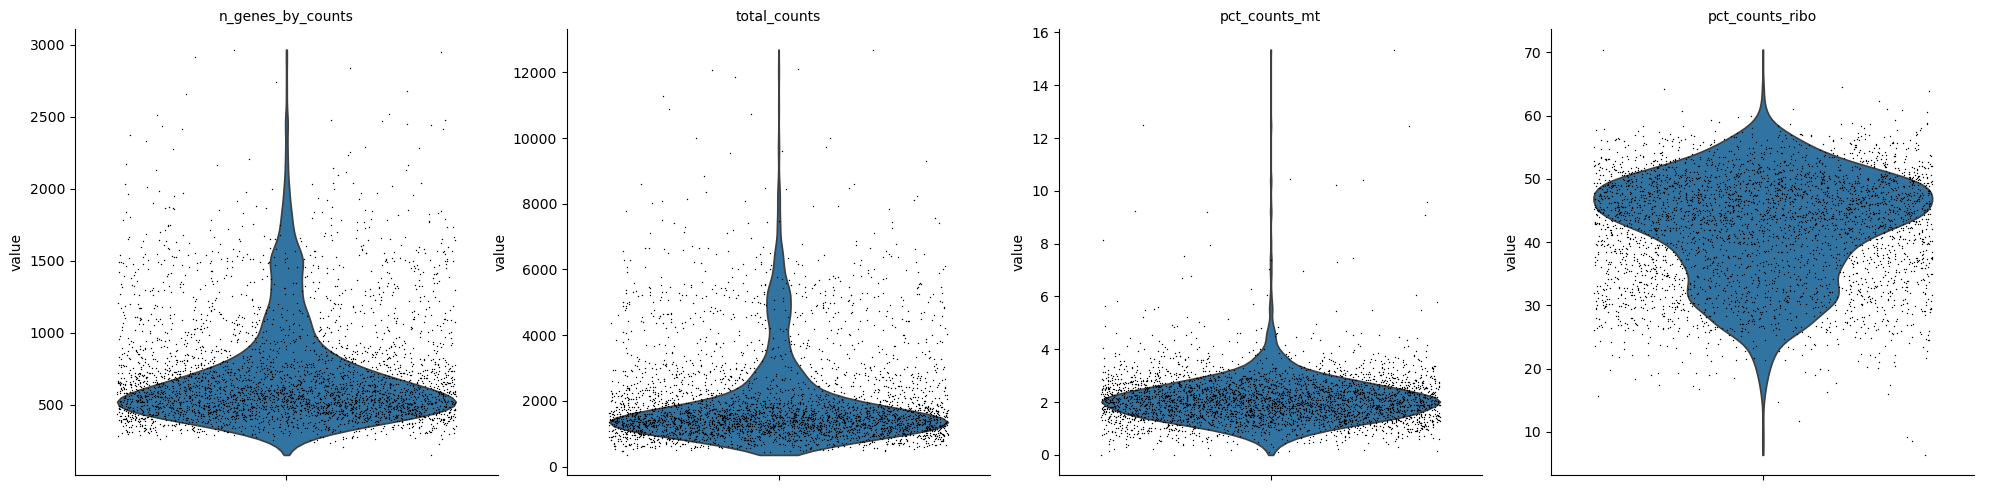

In [83]:
# mitochondrial genes & ribosomal genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt","pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
)

In [84]:
adata = adata[
    (adata.obs.n_genes_by_counts < 2000) & (adata.obs.n_genes_by_counts > 200) & (adata.obs.pct_counts_mt < 5),
    :,
].copy()

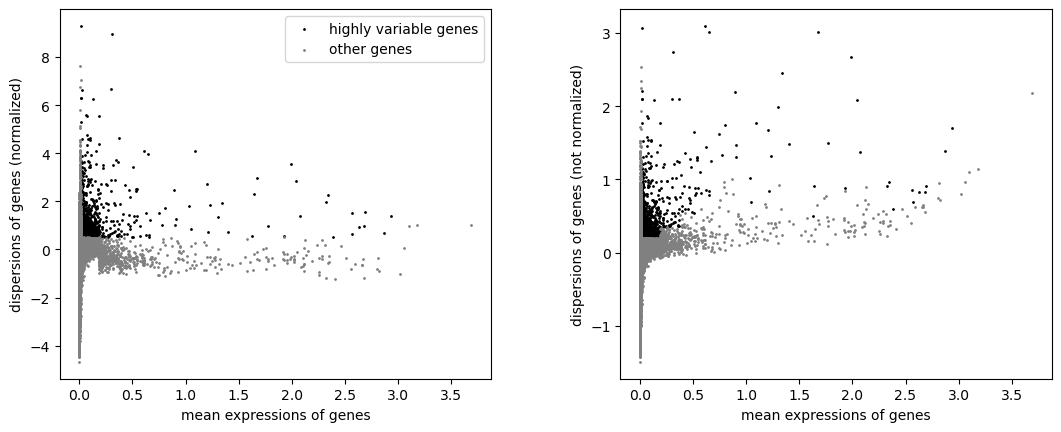

In [85]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pl.highly_variable_genes(adata)

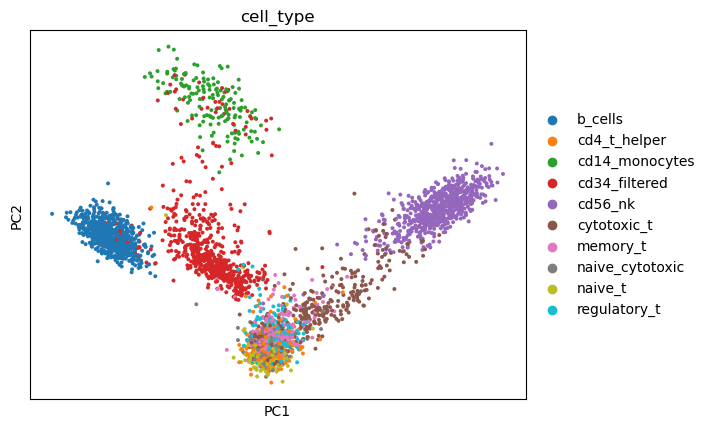

In [86]:
sc.tl.pca(adata)
sc.pl.pca(adata, color="cell_type")

## Differential gene expression analysis based on cell type information

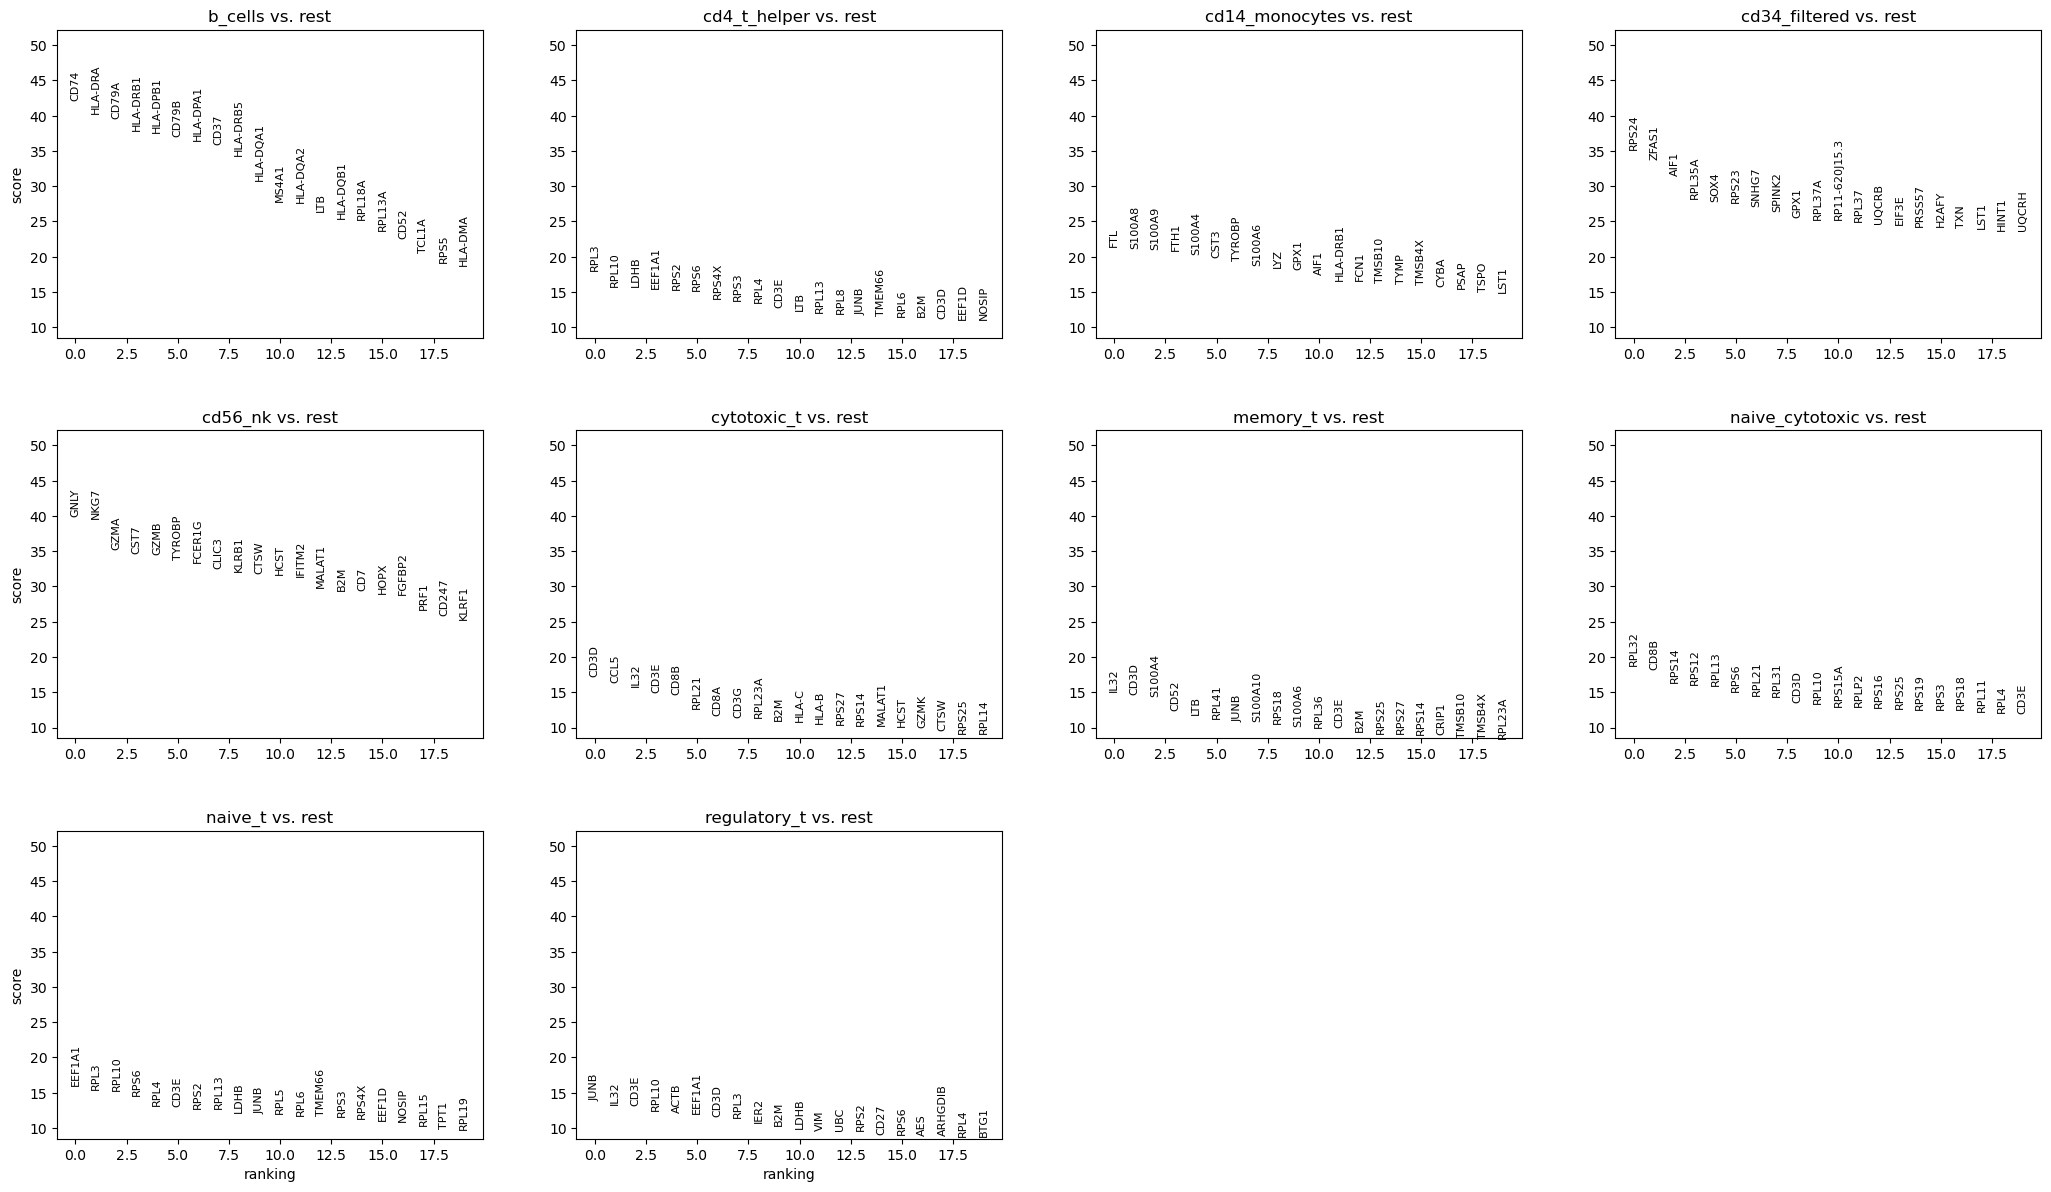

In [87]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata)

In [88]:
degs=sc.get.rank_genes_groups_df(adata,group=None, pval_cutoff = 0.01)
degs

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,b_cells,CD74,42.069515,4.475753,0.000000e+00,0.000000e+00
1,b_cells,HLA-DRA,40.280479,4.568464,0.000000e+00,0.000000e+00
2,b_cells,CD79A,39.598873,6.516940,0.000000e+00,0.000000e+00
3,b_cells,HLA-DRB1,37.813484,3.930968,0.000000e+00,0.000000e+00
4,b_cells,HLA-DPB1,37.526237,3.777007,3.439635e-308,9.676382e-305
...,...,...,...,...,...,...
5671,regulatory_t,RPL31,-13.281285,-0.728626,2.972488e-40,6.631468e-37
5672,regulatory_t,RPL37,-13.464501,-1.239405,2.530201e-41,7.117961e-38
5673,regulatory_t,RPL37A,-13.551299,-1.154468,7.784045e-42,2.737259e-38
5674,regulatory_t,RPS24,-13.607645,-1.352913,3.606816e-42,1.691116e-38


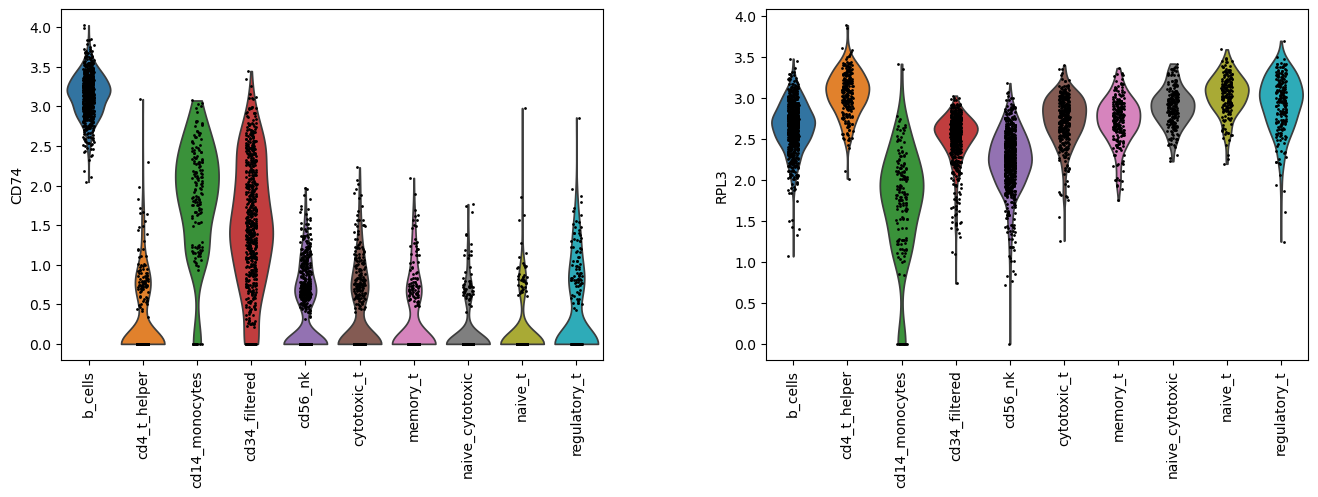

In [89]:
sc.pl.violin(adata, ["CD74", "RPL3"], groupby="cell_type",rotation=90,size=2)

## Enrichment Analysis using the degs

In [90]:
gene_sets = ['GO_Biological_Process_2025', 'KEGG_2021_Human','MSigDB_Hallmark_2020','Reactome_Pathways_2024']

In [91]:
results = {}
for type in degs['group'].unique():
    type_genes = degs[degs['group'] == type]['names'].tolist()
    enr = gp.enrichr(gene_list=type_genes,
                     gene_sets=gene_sets,
                     organism='human',
                     outdir=None)
    
    results[type] = enr
    print(f"Finished enrichment for type {type}")

Finished enrichment for type b_cells
Finished enrichment for type cd4_t_helper
Finished enrichment for type cd14_monocytes
Finished enrichment for type cd34_filtered
Finished enrichment for type cd56_nk
Finished enrichment for type cytotoxic_t
Finished enrichment for type memory_t
Finished enrichment for type naive_cytotoxic
Finished enrichment for type naive_t
Finished enrichment for type regulatory_t


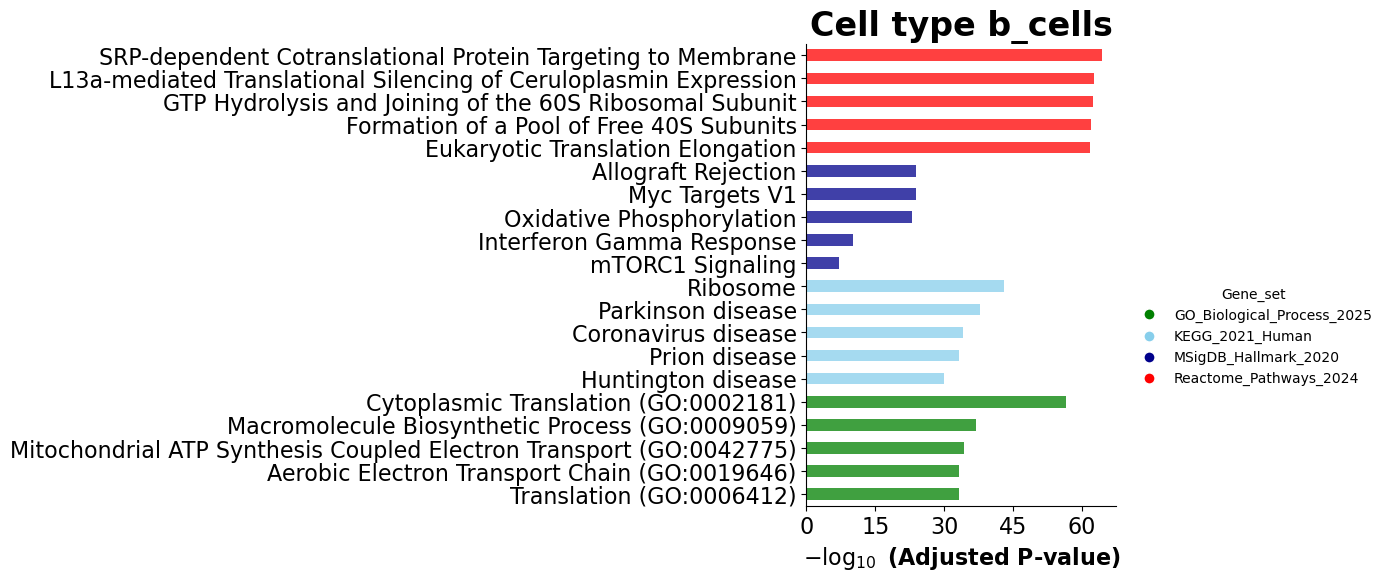

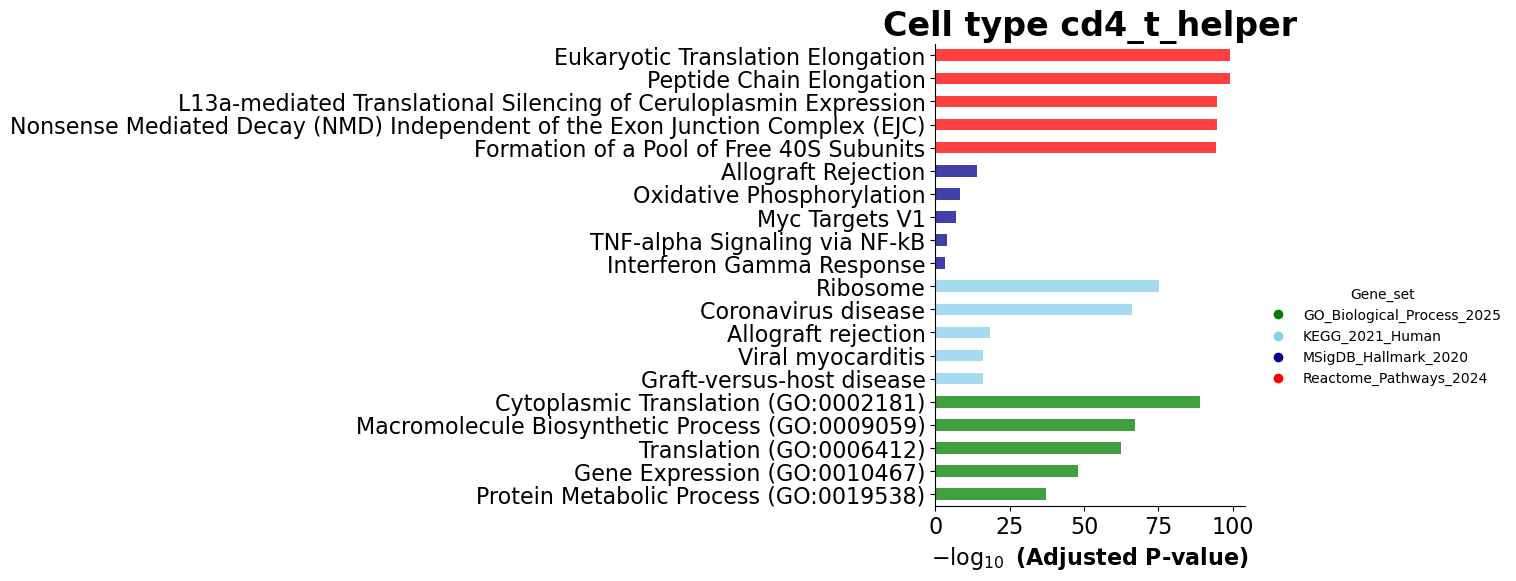

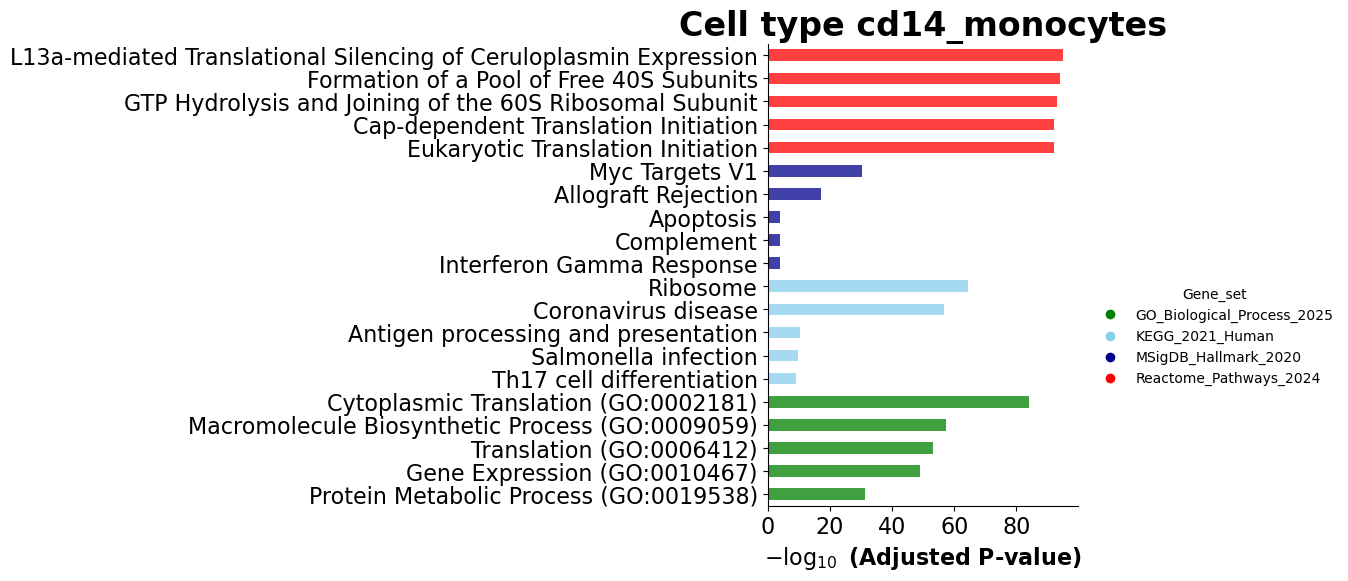

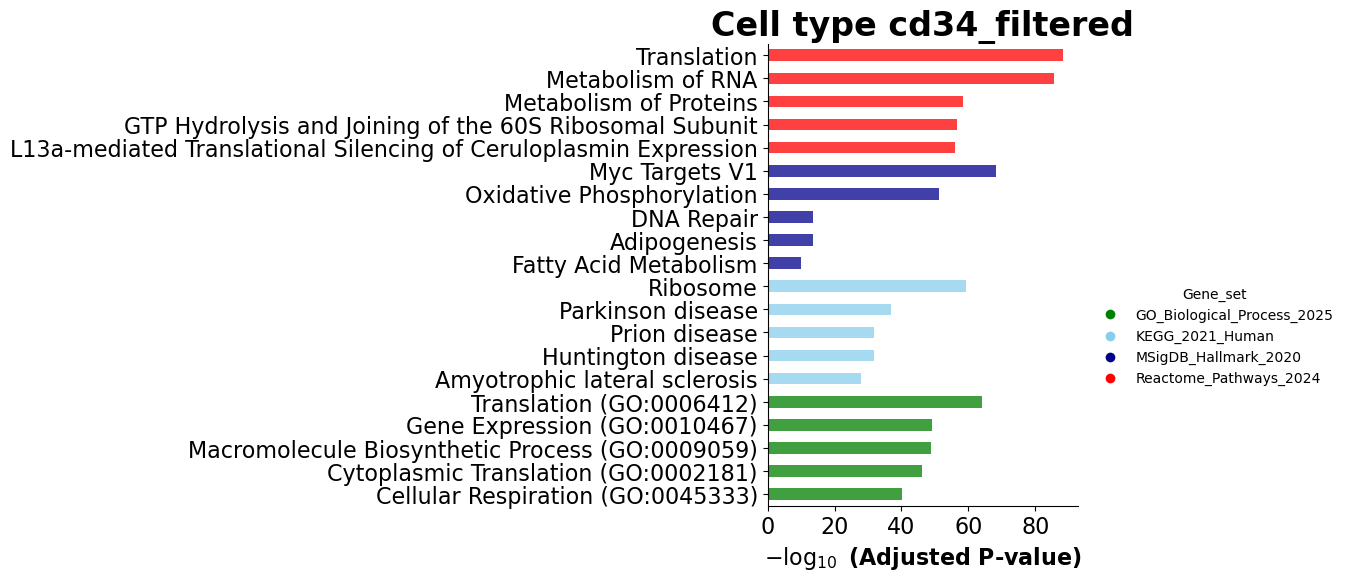

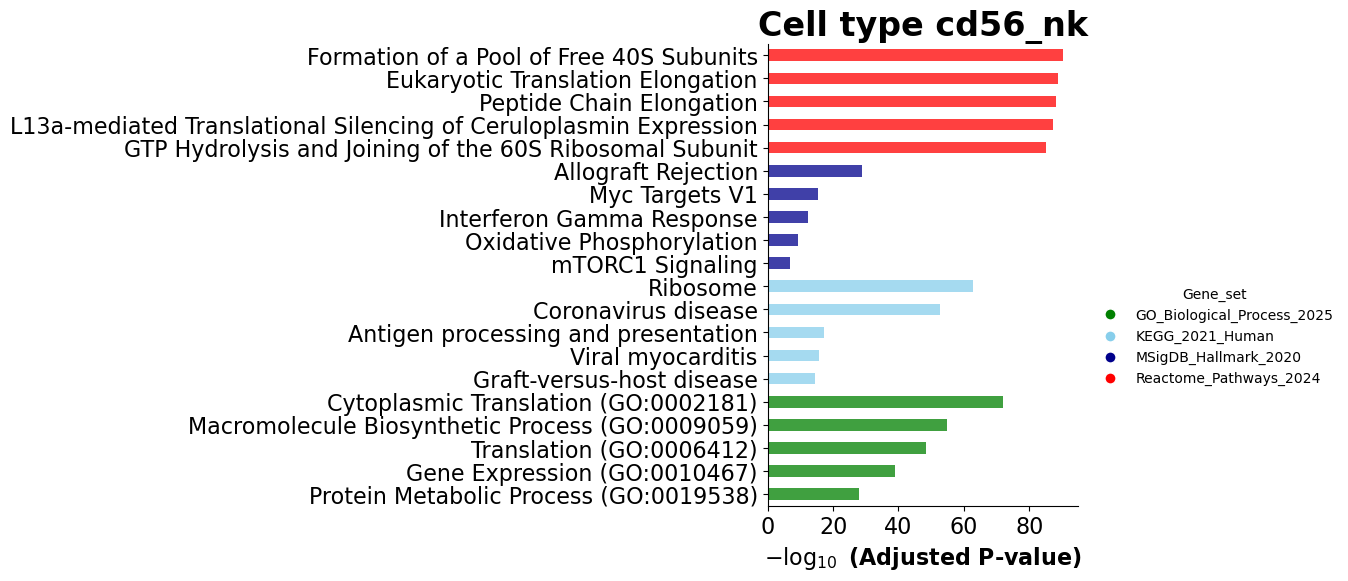

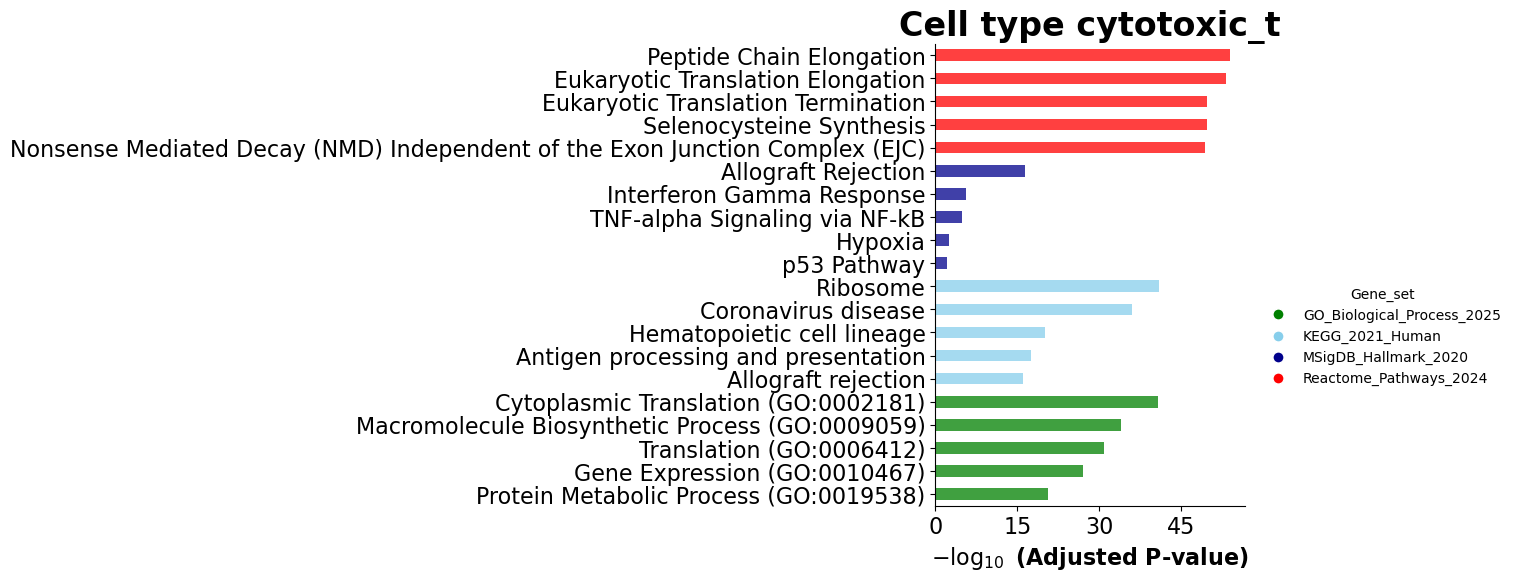

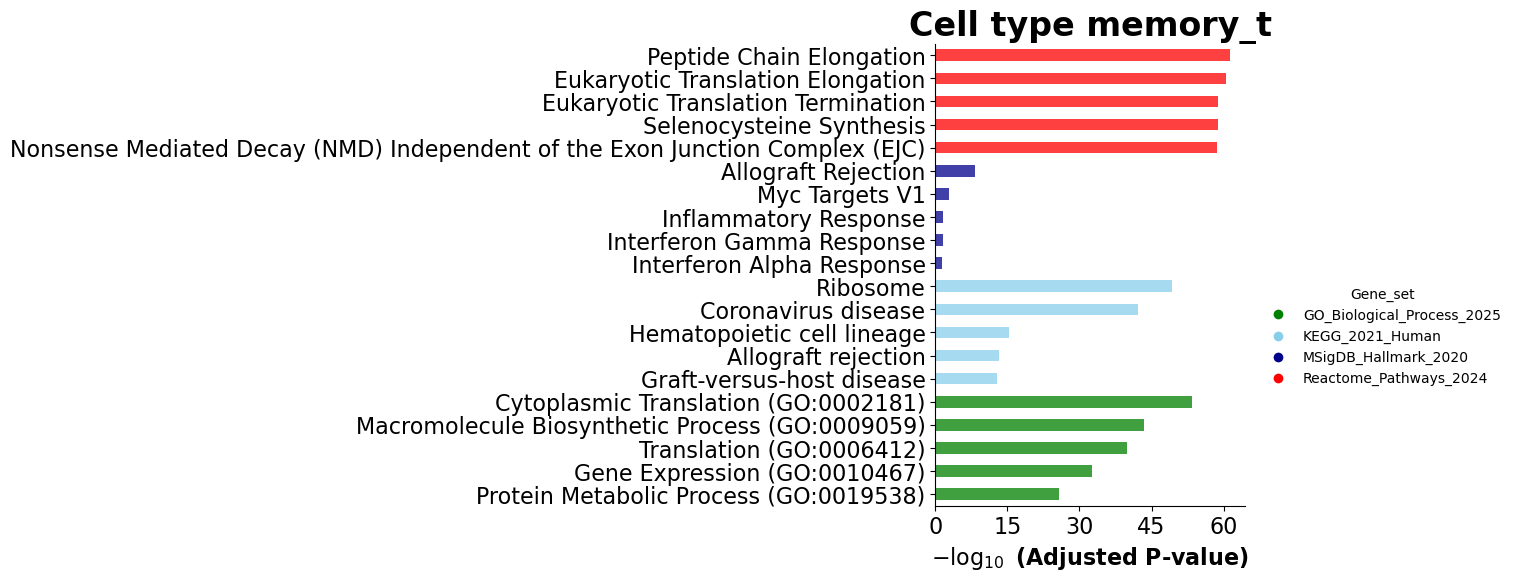

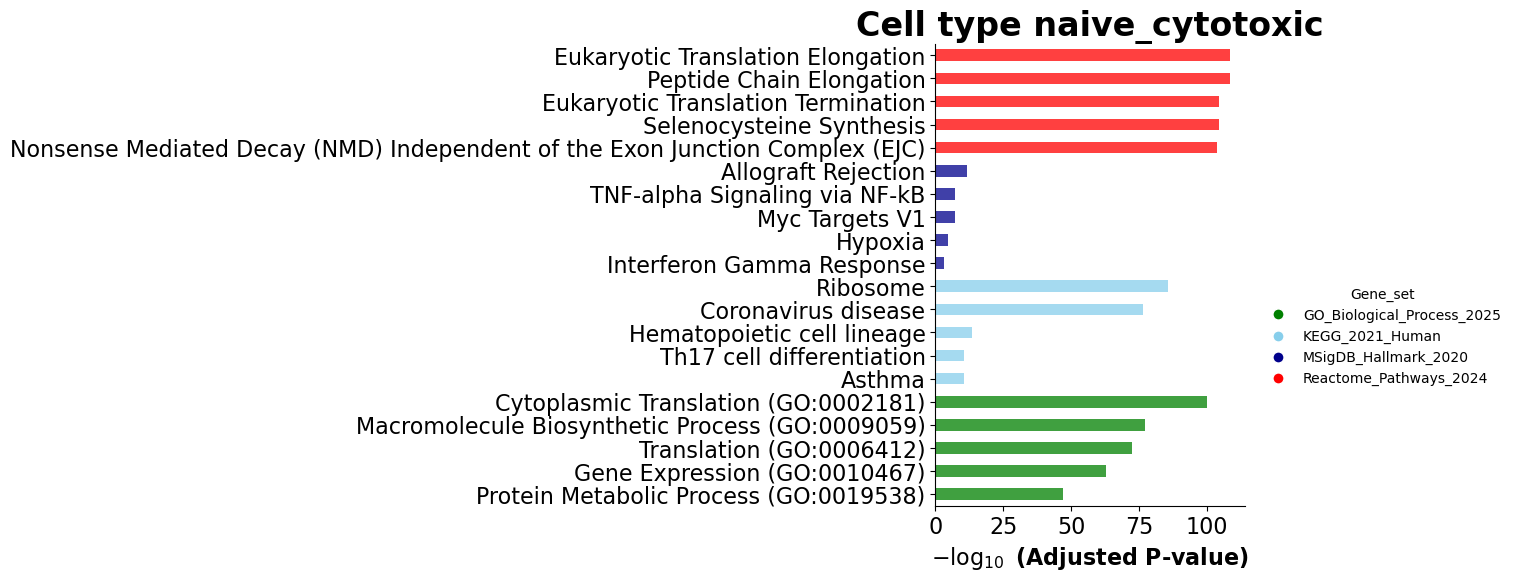

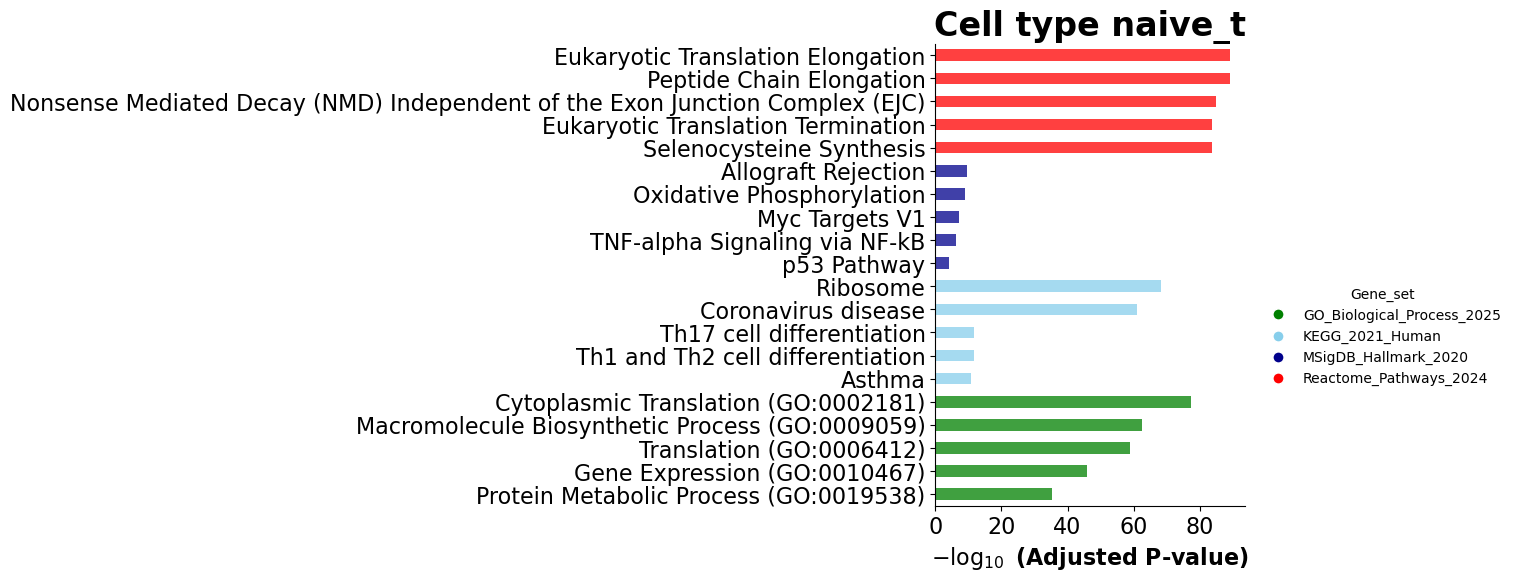

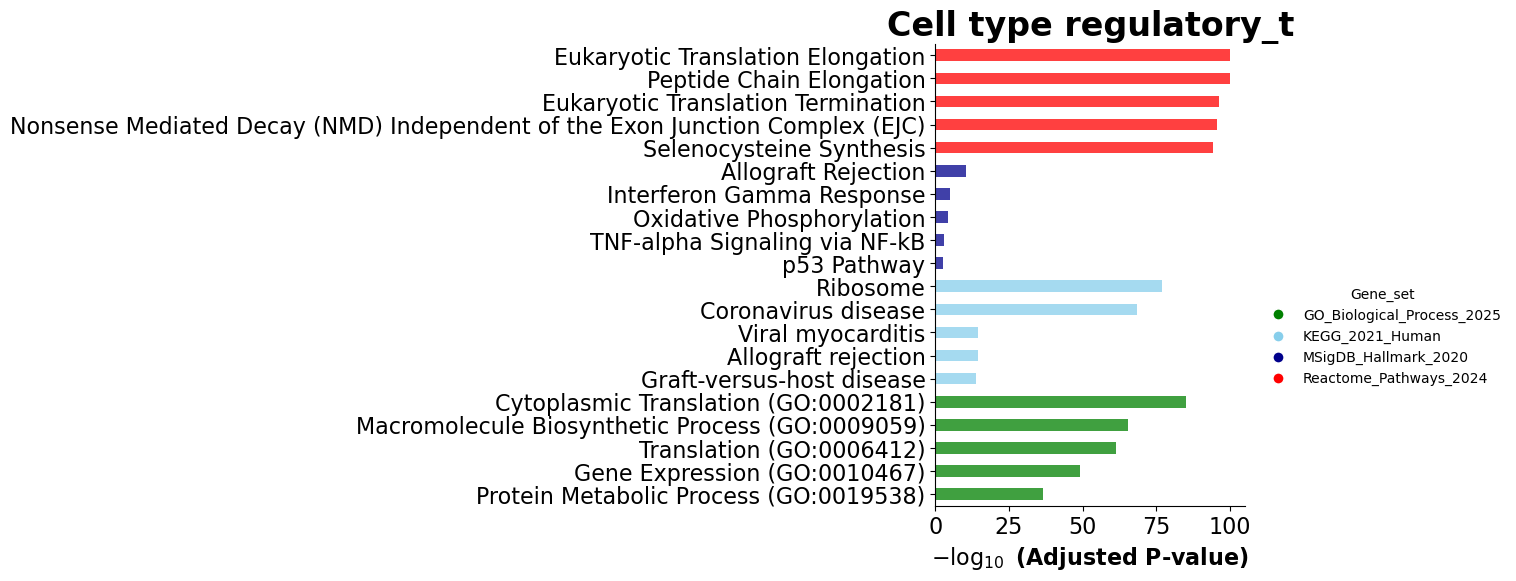

In [92]:
for type, enr_obj in results.items():
    res_df = enr_obj.results
    gp.barplot(res_df, 
            column="Adjusted P-value", 
            title=f"Cell type {type}",
            group='Gene_set',
            top_term=5,
            size=10,
            cutoff=0.05,
            color = {'KEGG_2021_Human': 'skyblue', 'GO_Biological_Process_2025':'green','MSigDB_Hallmark_2020':'darkblue','Reactome_Pathways_2024':'red'})
    plt.show()